# Ambiance — Model Training (Google Colab)
**Phase 4:** Train ResNet50 + custom head on the interior design dataset.

**Before running:** Make sure your Google Drive has this structure:
```
MyDrive/dl-project/
├── dataset_train/   ← 19 style subfolders
├── dataset_test/    ← 19 style subfolders
└── model.py
```
And confirm: **Runtime → Change runtime type → T4 GPU**

## 0. Mount Google Drive

In [ ]:
# Mounts your Google Drive at /content/drive/MyDrive — required to read the dataset and save the model.
# A browser popup will ask you to authorise access.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, os, json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# ── Paths ──────────────────────────────────────────────────────────────────────
DRIVE_DIR     = '/content/drive/MyDrive/dl-project'
TRAIN_DIR = '/content/dataset_train'
TEST_DIR  = '/content/dataset_test'
MODEL_PATH    = os.path.join(DRIVE_DIR, 'ambiance_model.h5')     # Best weights saved here
HISTORY_PATH  = os.path.join(DRIVE_DIR, 'training_history.json') # Training curves saved here
CURVES_PATH   = os.path.join(DRIVE_DIR, 'training_curves.png')   # Plot saved here

# Add Drive project folder to Python path so we can import model.py from Drive
sys.path.insert(0, DRIVE_DIR)

# Sanity checks — fix any that print False before continuing
print("GPU detected:      ", tf.config.list_physical_devices('GPU'))
print("Train dir exists:  ", os.path.exists(TRAIN_DIR))
print("Test dir exists:   ", os.path.exists(TEST_DIR))
print("model.py exists:   ", os.path.exists(os.path.join(DRIVE_DIR, 'model.py')))

GPU detected:       [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train dir exists:   False
Test dir exists:    False
model.py exists:    True


In [ ]:
import shutil

print("Copying dataset to local Colab storage — do this once per session...")
shutil.copytree('/content/drive/MyDrive/dl-project/dataset_train', '/content/dataset_train')
shutil.copytree('/content/drive/MyDrive/dl-project/dataset_test',  '/content/dataset_test')
print("Done.")


Copying dataset to local Colab storage — do this once per session...
Done.


## 1. Build data generators

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.15
SEED       = 42

# ResNet50 was trained with channel-mean subtraction (not simple /255 scaling).
# Using preprocess_input instead of rescale=1/255 is critical — the frozen base
# produces meaningful features only when it sees inputs in the same scale it was trained on.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=20,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    validation_split=VAL_SPLIT
)

# Evaluation generator — no augmentation so metrics reflect true real-world performance
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)
test_gen = eval_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

NUM_CLASSES = train_gen.num_classes
assert NUM_CLASSES == 19, f"Expected 19 classes, got {NUM_CLASSES} — check for missing or misnamed folders on Drive."

print(f"Training images:   {train_gen.samples}")
print(f"Validation images: {val_gen.samples}")
print(f"Test images:       {test_gen.samples}")
print(f"Classes ({NUM_CLASSES}): {list(train_gen.class_indices.keys())}")

Found 12654 images belonging to 19 classes.
Found 2222 images belonging to 19 classes.
Found 3729 images belonging to 19 classes.
Training images:   12654
Validation images: 2222
Test images:       3729
Classes (19): ['asian', 'coastal', 'contemporary', 'craftsman', 'eclectic', 'farmhouse', 'french-country', 'industrial', 'mediterranean', 'mid-century-modern', 'modern', 'rustic', 'scandinavian', 'shabby-chic-style', 'southwestern', 'traditional', 'transitional', 'tropical', 'victorian']


## 2. Class balance check
If one class has far more images than others the model will be biased toward predicting it.
We compute class weights to compensate — the model penalises mistakes on smaller classes more heavily.

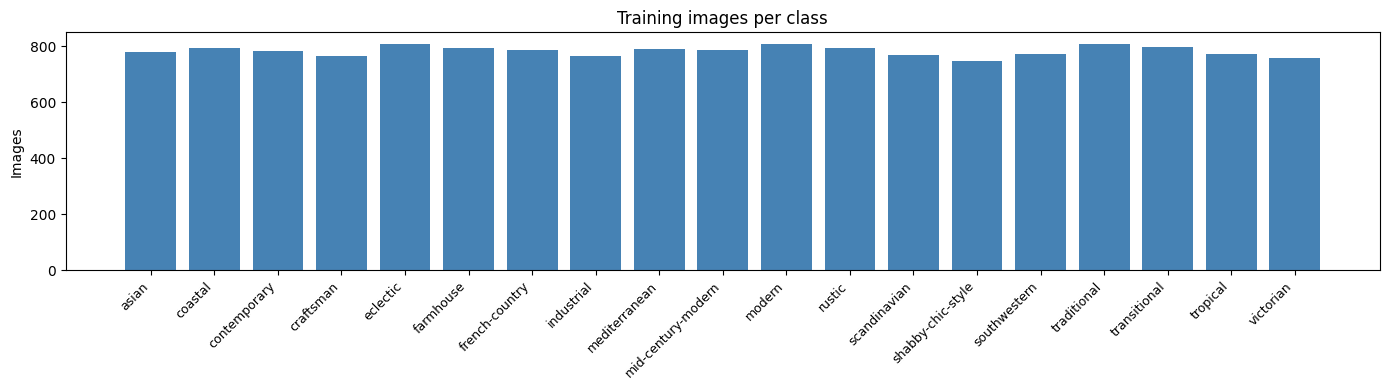

Min: 746  |  Max: 809  |  Ratio: 1.08x

Class weights (higher = model penalises mistakes more):
   0  asian                      weight: 1.005
   1  coastal                    weight: 0.987
   2  contemporary               weight: 1.002
   3  craftsman                  weight: 1.025
   4  eclectic                   weight: 0.968
   5  farmhouse                  weight: 0.985
   6  french-country             weight: 0.994
   7  industrial                 weight: 1.025
   8  mediterranean              weight: 0.993
   9  mid-century-modern         weight: 0.994
  10  modern                     weight: 0.968
  11  rustic                     weight: 0.987
  12  scandinavian               weight: 1.020
  13  shabby-chic-style          weight: 1.049
  14  southwestern               weight: 1.014
  15  traditional                weight: 0.968
  16  transitional               weight: 0.984
  17  tropical                   weight: 1.014
  18  victorian                  weight: 1.031


In [ ]:
class_names = list(train_gen.class_indices.keys())

# Count images per class folder directly from disk (before the val split)
counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in class_names]

plt.figure(figsize=(14, 4))
plt.bar(class_names, counts, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Images')
plt.title('Training images per class')
plt.tight_layout()
plt.show()

print(f"Min: {min(counts)}  |  Max: {max(counts)}  |  Ratio: {max(counts)/min(counts):.2f}x")

# compute_class_weight assigns higher weight to underrepresented classes.
# 'balanced' mode sets weight = total_samples / (num_classes * class_count), so rare classes get upweighted.
# This is passed to model.fit() so the loss function cares more about mistakes on smaller classes.
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))

print("\nClass weights (higher = model penalises mistakes more):")
for idx, name in enumerate(class_names):
    print(f"  {idx:>2}  {name:<25}  weight: {class_weight_dict[idx]:.3f}")

## 3. Build the model

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model(MODEL_PATH)

# Get the ResNet50 base by name so we can inspect it
base_model = model.get_layer('resnet50')

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Loaded model. Trainable layers: {trainable_count}")
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,648,595 (94.03 MB)

 Trainable params: 1,059,859 (4.04 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

## 4a. Train the custom head (frozen ResNet50 base)
In this phase only the custom ANN head is trained — the ResNet50 base stays frozen.
We train until val_loss stops improving, then move to fine-tuning.

In [ ]:
# EarlyStopping: stops after 5 epochs with no val_loss improvement, then rewinds to the best weights.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# ModelCheckpoint: saves to Drive only on a new best val_loss — persists across session disconnects.
checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)

# ReduceLROnPlateau: halves the learning rate after 3 stalled epochs to help escape flat loss regions.
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history_head = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,  # Compensates for any class imbalance
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

print(f"Phase 4a complete. Best val accuracy: {max(history_head.history['val_accuracy'])*100:.1f}%")

Epoch 1/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.0915 - loss: 3.3258
Epoch 1: val_loss improved from None to 2.52067, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 272s 647ms/step - accuracy: 0.1270 - loss: 3.1131 - val_accuracy: 0.2322 - val_loss: 2.5207 - learning_rate: 1.0000e-04
Epoch 2/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.2055 - loss: 2.7253
Epoch 2: val_loss improved from 2.52067 to 2.43327, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 236s 596ms/step - accuracy: 0.2144 - loss: 2.7009 - val_accuracy: 0.2543 - val_loss: 2.4333 - learning_rate: 1.0000e-04
Epoch 3/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.2457 - loss: 2.5053
Epoch 3: val_loss improved from 2.43327 to 2.38762, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 238s 601ms/step - accuracy: 0.2497 - loss: 2.5118 - val_accuracy: 0.2750 - val_loss: 2.3876 - learning_rate: 1.0000e-04
Epoch 4/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.2670 - loss: 2.4231
Epoch 4: val_loss improved from 2.38762 to 2.35974, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 235s 594ms/step - accuracy: 0.2734 - loss: 2.4053 - val_accuracy: 0.2777 - val_loss: 2.3597 - learning_rate: 1.0000e-04
Epoch 5/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.3001 - loss: 2.3057
Epoch 5: val_loss improved from 2.35974 to 2.34345, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 236s 597ms/step - accuracy: 0.3279 - loss: 2.1899 - val_accuracy: 0.2984 - val_loss: 2.3207 - learning_rate: 1.0000e-04
Epoch 8/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.3451 - loss: 2.1281
Epoch 8: val_loss improved from 2.32066 to 2.29826, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 236s 595ms/step - accuracy: 0.3471 - loss: 2.1289 - val_accuracy: 0.3092 - val_loss: 2.2983 - learning_rate: 1.0000e-04
Epoch 9/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.3628 - loss: 2.0741
Epoch 9: val_loss improved from 2.29826 to 2.28966, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 239s 605ms/step - accuracy: 0.3560 - loss: 2.0893 - val_accuracy: 0.3020 - val_loss: 2.2897 - learning_rate: 1.0000e-04
Epoch 10/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.3681 - loss: 2.0382
Epoch 10: val_loss improved from 2.28966 to 2.26974, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 240s 607ms/step - accuracy: 0.3700 - loss: 2.0399 - val_accuracy: 0.3146 - val_loss: 2.2697 - learning_rate: 1.0000e-04
Epoch 11/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.3719 - loss: 2.0056
Epoch 11: val_loss did not improve from 2.26974
396/396 ━━━━━━━━━━━━━━━━━━━━ 236s 596ms/step - accuracy: 0.3748 - loss: 2.0110 - val_accuracy: 0.3069 - val_loss: 2.2808 - learning_rate: 1.0000e-04
Epoch 12/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.3924 - loss: 1.9664
Epoch 12: val_loss did not improve from 2.26974
396/396 ━━━━━━━━━━━━━━━━━━━━ 234s 591ms/step - accuracy: 0.3914 - loss: 1.9738 - val_accuracy: 0.3020 - val_loss: 2.3122 - learning_rate: 1.0000e-04
Epoch 13/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.4089 - loss: 1.9083
Epoch 13: val_loss did not improve from 2.26974

Epoch 13: ReduceLROnPlateau reducing learning rate to


Epoch 15: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 235s 595ms/step - accuracy: 0.4226 - loss: 1.8652 - val_accuracy: 0.3159 - val_loss: 2.2612 - learning_rate: 5.0000e-05
Epoch 16/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.4254 - loss: 1.8465
Epoch 16: val_loss did not improve from 2.26122
396/396 ━━━━━━━━━━━━━━━━━━━━ 235s 592ms/step - accuracy: 0.4250 - loss: 1.8394 - val_accuracy: 0.3083 - val_loss: 2.2925 - learning_rate: 5.0000e-05
Epoch 17/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.4395 - loss: 1.7988
Epoch 17: val_loss did not improve from 2.26122
396/396 ━━━━━━━━━━━━━━━━━━━━ 235s 594ms/step - accuracy: 0.4361 - loss: 1.8106 - val_accuracy: 0.3011 - val_loss: 2.2940 - learning_rate: 5.0000e-05
Epoch 18/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.4517 - loss: 1.7852
Epoch 18: val_loss did not improve from 2.26122

Epoch 18: ReduceLROnPlateau reducing learning rate to

## 4b. Fine-tune the top ResNet50 layers
Now that the custom head has learned to classify interior styles, we unfreeze the top 30 layers
of ResNet50 and continue training with a much lower learning rate.

**Why fine-tune?**
The frozen ResNet50 layers learned general image features (edges, textures) from ImageNet.
Fine-tuning lets those top layers also adapt to the specific visual patterns of interior design styles
(colour palettes, materials, structural elements) — pushing accuracy significantly higher.

**Why only the top 30 layers?**
Early ResNet layers detect universal low-level features (edges, gradients) that transfer perfectly.
Only the later layers need to adapt to our domain. Unfreezing all 175 layers with our dataset size would overfit.

**Why 1e-5 learning rate?**
10× lower than the head training rate. The ResNet weights are already good — we nudge them, not overwrite them.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Load the saved model — weights and unfrozen layer state are preserved in the .h5
model = tf.keras.models.load_model(MODEL_PATH)

print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}")

# Recompile with fine-tuning learning rate (must recompile after loading to reset optimizer state)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_ft     = ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr_ft      = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

history_fine = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_ft, checkpoint_ft, reduce_lr_ft]
)

print(f"Phase 4b complete. Best val accuracy: {max(history_fine.history['val_accuracy'])*100:.1f}%")


Trainable layers after unfreezing: 36
Epoch 1/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.3579 - loss: 2.0633
Epoch 1: val_loss improved from None to 2.32875, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 284s 657ms/step - accuracy: 0.3718 - loss: 2.0318 - val_accuracy: 0.3065 - val_loss: 2.3287 - learning_rate: 1.0000e-05
Epoch 2/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.3943 - loss: 1.9224
Epoch 2: val_loss improved from 2.32875 to 2.30936, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 248s 627ms/step - accuracy: 0.4015 - loss: 1.9066 - val_accuracy: 0.3060 - val_loss: 2.3094 - learning_rate: 1.0000e-05
Epoch 3/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.4310 - loss: 1.8262
Epoch 3: val_loss improved from 2.30936 to 2.27401, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 250s 631ms/step - accuracy: 0.4309 - loss: 1.8246 - val_accuracy: 0.3155 - val_loss: 2.2740 - learning_rate: 1.0000e-05
Epoch 4/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.4533 - loss: 1.7712
Epoch 4: val_loss did not improve from 2.27401
396/396 ━━━━━━━━━━━━━━━━━━━━ 251s 635ms/step - accuracy: 0.4510 - loss: 1.7702 - val_accuracy: 0.3141 - val_loss: 2.2949 - learning_rate: 1.0000e-05
Epoch 5/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.4729 - loss: 1.6866
Epoch 5: val_loss improved from 2.27401 to 2.27359, saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 244s 616ms/step - accuracy: 0.4667 - loss: 1.7125 - val_accuracy: 0.3267 - val_loss: 2.2736 - learning_rate: 1.0000e-05
Epoch 6/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.4939 - loss: 1.6381
Epoch 6: val_loss did not improve from 2.27359
396/396 ━━━━━━━━━━━━━━━━━━━━ 247s 624ms/step - accuracy: 0.4906 - loss: 1.6483 - val_accuracy: 0.3263 - val_loss: 2.2758 - learning_rate: 1.0000e-05
Epoch 7/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.5092 - loss: 1.5792
Epoch 7: val_loss did not improve from 2.27359
396/396 ━━━━━━━━━━━━━━━━━━━━ 238s 600ms/step - accuracy: 0.5048 - loss: 1.5946 - val_accuracy: 0.3195 - val_loss: 2.2888 - learning_rate: 1.0000e-05
Epoch 8/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.5205 - loss: 1.5249
Epoch 8: val_loss improved from 2.27359 to 2.25886, saving model to /content/drive/MyDrive/dl-project/ambian


Epoch 8: finished saving model to /content/drive/MyDrive/dl-project/ambiance_model.h5
396/396 ━━━━━━━━━━━━━━━━━━━━ 248s 625ms/step - accuracy: 0.5205 - loss: 1.5342 - val_accuracy: 0.3231 - val_loss: 2.2589 - learning_rate: 1.0000e-05
Epoch 9/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.5341 - loss: 1.4814
Epoch 9: val_loss did not improve from 2.25886
396/396 ━━━━━━━━━━━━━━━━━━━━ 249s 628ms/step - accuracy: 0.5341 - loss: 1.4891 - val_accuracy: 0.3164 - val_loss: 2.2925 - learning_rate: 1.0000e-05
Epoch 10/20
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.5466 - loss: 1.4488
Epoch 10: val_loss did not improve from 2.25886
396/396 ━━━━━━━━━━━━━━━━━━━━ 239s 603ms/step - accuracy: 0.5482 - loss: 1.4463 - val_accuracy: 0.3281 - val_loss: 2.2644 - learning_rate: 1.0000e-05
Epoch 11/20
 96/396 ━━━━━━━━━━━━━━━━━━━━ 2:29 498ms/step - accuracy: 0.5731 - loss: 1.3807

KeyboardInterrupt: 

## 5. Plot training curves
Both phases are plotted together. The vertical line marks where fine-tuning began.

In [ ]:
acc      = history_fine.history['accuracy']
val_acc  = history_fine.history['val_accuracy']
loss     = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss,     label='Training loss')
axes[0].plot(val_loss, label='Validation loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()

axes[1].plot(acc,     label='Training accuracy')
axes[1].plot(val_acc, label='Validation accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Training vs Validation — Phase 4b (fine-tuned)', fontsize=12)
plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=150)
plt.show()
print(f"Curves saved to: {CURVES_PATH}")

## 6. Save training history
Saves all metrics to a JSON file on Drive so you can re-plot curves in future sessions without retraining.

In [ ]:
full_history = {
    'accuracy':     acc,
    'val_accuracy': val_acc,
    'loss':         loss,
    'val_loss':     val_loss,
}

with open(HISTORY_PATH, 'w') as f:
    json.dump(full_history, f)

print(f"History saved to: {HISTORY_PATH}")

## 7. Final results

In [ ]:
test_loss, test_acc = model.evaluate(test_gen, verbose=1)

print(f"\n── Results ────────────────────────────────")
print(f"Fine-tuning epochs:  {len(history_fine.history['loss'])}")
print(f"Best val accuracy:   {max(val_acc)*100:.1f}%")
print(f"Test accuracy:       {test_acc*100:.1f}%")
print(f"Model saved to:      {MODEL_PATH}")
print(f"\nNext step: 03_evaluation.ipynb — F1 per class and confusion matrix.")